## Objective

The objective of this data analytics study is to investigate the relationship between ambient temperature and daily yield in a solar photovoltaic (PV) plant. By analyzing how variations in ambient temperature affect the daily energy output, we aim to identify optimal operating conditions and potential efficiency losses. The insights from this analysis will help in optimizing the performance of solar PV systems, guiding maintenance schedules, and improving energy yield predictions. Additionally, understanding these dynamics will provide valuable information for solar plant operators and engineers to enhance the overall efficiency and reliability of solar power generation.

## Analysis using R Programming

In [1]:
# loading packages

library(tidyverse) 

list.files(path = "../input")


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


[1] "solar-power-generation-data"

In [2]:
library(dplyr)

# import plant 2 generation data table

plant_generation_data <- read_csv('/kaggle/input/solar-power-generation-data/Plant_2_Generation_Data.csv')

# import plant 2 weather sensor data table

weather_data <- read_csv('/kaggle/input/solar-power-generation-data/Plant_2_Weather_Sensor_Data.csv')

head(plant_generation_data)

head(weather_data)



Rows: 67698 Columns: 7


── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): SOURCE_KEY
dbl  (5): PLANT_ID, DC_POWER, AC_POWER, DAILY_YIELD, TOTAL_YIELD
dttm (1): DATE_TIME



ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 3259 Columns: 6


── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): SOURCE_KEY
dbl  (4): PLANT_ID, AMBIENT_TEMPERATURE, MODULE_TEMPERATURE, IRRADIATION
dttm (1): DATE_TIME



ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
<dttm>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
2020-05-15,4136001,4UPUqMRk7TRMgml,0,0,9425.0000,2429011
2020-05-15,4136001,81aHJ1q11NBPMrL,0,0,0.0000,1215278736
2020-05-15,4136001,9kRcWv60rDACzjR,0,0,3075.3333,2247719577
2020-05-15,4136001,Et9kgGMDl729KT4,0,0,269.9333,1704250
2020-05-15,4136001,IQ2d7wF4YD8zU1Q,0,0,3177.0000,19941526
2020-05-15,4136001,LYwnQax7tkwH5Cb,0,0,1872.5000,1794958634


DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
<dttm>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
2020-05-15 00:00:00,4136001,iq8k7ZNt4Mwm3w0,27.00476,25.06079,0
2020-05-15 00:15:00,4136001,iq8k7ZNt4Mwm3w0,26.88081,24.42187,0
2020-05-15 00:30:00,4136001,iq8k7ZNt4Mwm3w0,26.68206,24.42729,0
2020-05-15 00:45:00,4136001,iq8k7ZNt4Mwm3w0,26.50059,24.42068,0
2020-05-15 01:00:00,4136001,iq8k7ZNt4Mwm3w0,26.59615,25.08821,0
2020-05-15 01:15:00,4136001,iq8k7ZNt4Mwm3w0,26.51274,25.31797,0


In [3]:
# divide DAILY_YIELD column by 1000 to scale with AMBIENT_TEMPERATURE data

plant_generation_data2 <- plant_generation_data %>%
    mutate(new_daily_yield = DAILY_YIELD/1000) %>%
    select(c(DATE_TIME, new_daily_yield))

head(plant_generation_data2)

# keep only 2 columns from weather_data

weather_data2 <- weather_data %>%
    select(c(DATE_TIME, AMBIENT_TEMPERATURE))

head(weather_data2)


DATE_TIME,new_daily_yield
<dttm>,<dbl>
2020-05-15,9.4250000
2020-05-15,0.0000000
2020-05-15,3.0753333
2020-05-15,0.2699333
2020-05-15,3.1770000
2020-05-15,1.8725000


DATE_TIME,AMBIENT_TEMPERATURE
<dttm>,<dbl>
2020-05-15 00:00:00,27.00476
2020-05-15 00:15:00,26.88081
2020-05-15 00:30:00,26.68206
2020-05-15 00:45:00,26.50059
2020-05-15 01:00:00,26.59615
2020-05-15 01:15:00,26.51274


In [4]:
# join the 2 datasets

ambientTemp_vs_dailyYield <- left_join(weather_data2, plant_generation_data2, by = c('DATE_TIME' = 'DATE_TIME'))

# renaming columns before plotting

ambientTemp_vs_dailyYield_graph <- ambientTemp_vs_dailyYield %>%
    rename(
        date_and_time = DATE_TIME,
        ambient_temperature = AMBIENT_TEMPERATURE,
        daily_yield = new_daily_yield
    )

as_tibble(ambientTemp_vs_dailyYield_graph)

date_and_time,ambient_temperature,daily_yield
<dttm>,<dbl>,<dbl>
2020-05-15 00:00:00,27.00476,9.4250000
2020-05-15 00:00:00,27.00476,0.0000000
2020-05-15 00:00:00,27.00476,3.0753333
2020-05-15 00:00:00,27.00476,0.2699333
2020-05-15 00:00:00,27.00476,3.1770000
2020-05-15 00:00:00,27.00476,1.8725000
2020-05-15 00:00:00,27.00476,1.0943571
2020-05-15 00:00:00,27.00476,5.6922000
2020-05-15 00:00:00,27.00476,1.8662000


[1] 0.3217847


`geom_smooth()` using formula = 'y ~ x'


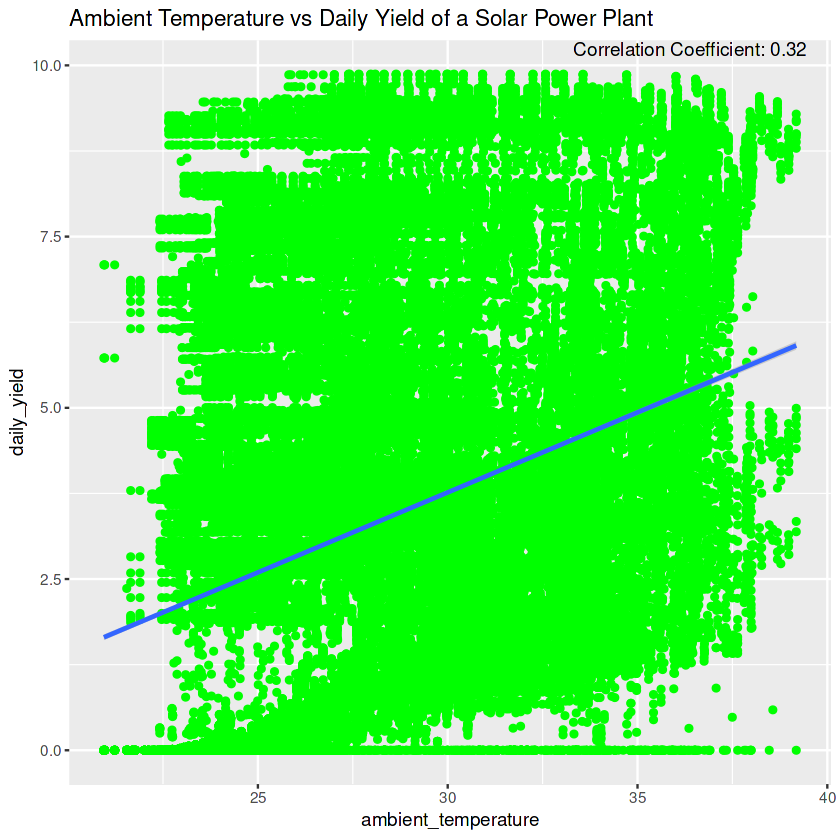

In [5]:
library(ggplot2)

# calculating the correlation coefficient

correlation_coefficient <- cor(ambientTemp_vs_dailyYield_graph$ambient_temperature, ambientTemp_vs_dailyYield_graph$daily_yield, use = "complete.obs")

print(correlation_coefficient)

# plotting the graph

ggplot(data = ambientTemp_vs_dailyYield_graph, aes(x = ambient_temperature, y = daily_yield)) +
    geom_point(color="green") + 
    geom_smooth(method = "lm") +
    labs(title="Ambient Temperature vs Daily Yield of a Solar Power Plant") +
    annotate("text", x = Inf, y = Inf, label = paste("Correlation Coefficient:", round(correlation_coefficient, 2)), hjust = 1.1, vjust = 1.1)



## Result

The analysis of the relationship between ambient temperature and the daily yield of a solar power plant revealed a correlation coefficient of 0.32. This value indicates a weak positive correlation between the two variables. 

A correlation coefficient of 0.32 suggests that, while there is a tendency for daily yield to increase with rising ambient temperatures, the relationship is not strong. This weak correlation might be due to several factors, such as the efficiency losses in solar panels at higher temperatures or the impact of other environmental variables not considered in the analysis. 

## Insights 

For solar power plant operators and designers, these findings imply that while temperature has some influence on power generation, it is not the sole factor determining efficiency. Further investigation into other factors, such as solar irradiance, panel technology, and maintenance practices, could provide a more comprehensive understanding of the determinants of daily yield.